# 21_forward_model_inverted_pendulum.ipynb — Phase 1 (MuJoCo InvertedPendulum)
**Model-Based RL:** Forward Model + Random Shooting MPC + **Noisy-PPO** veri toplama + **Render demoları**

Bu defter:
- Ortam: **InvertedPendulum-v4** (MuJoCo).
- Veri: **Kısa PPO (10k)** ile “akıllı ama keşifçi” politika → aksiyona **Gaussian gürültü** ekleyerek **100k** adım veri.
- İleri model: Büyük MLP, delta-state. **1-step** ve **k-step (5/10) seq MSE**.
- Planlayıcı: **Random Shooting MPC** (Gaussian/Uniform).
- Karşılaştırma: **Gerçek vs İleri model** (x, xdot, theta, thetadot) zaman-serisi + RMSE/MSE.
- Render: **Pygame** demosu (MPC ve PPO).  
- Klasörleme/TB: `runs/Phase 1/21_forward_model_inverted_pendulum/<RUN_ID>/...`.

## 1) Kurulum (gerekiyorsa)

In [1]:
# %pip install -U gymnasium mujoco stable-baselines3 tensorboard pandas matplotlib tqdm pygame

## 2) Kütüphaneler & Bootstrap

In [2]:
import sys, os, time, uuid, json, random, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import set_random_seed
from tensorboard.backend.event_processing import event_accumulator as ea

class RLBootstrap:
    def __init__(self, phase, notebook, step, env_id, seed=42):
        self.phase, self.notebook, self.step, self.env_id = phase, notebook, step, env_id
        self.seed = seed
        set_random_seed(seed); np.random.seed(seed); random.seed(seed)
        self.run_id   = time.strftime('%Y%m%d-%H%M%S') + f"-{uuid.uuid4().hex[:6]}"
        self.root_dir = os.path.join("runs", self.phase, self.notebook, self.run_id)
        self.ckpt_dir = os.path.join(self.root_dir, "checkpoints")
        self.mon_dir  = os.path.join(self.root_dir, "monitor")
        os.makedirs(self.ckpt_dir, exist_ok=True); os.makedirs(self.mon_dir, exist_ok=True)
        self._write_meta()
    def algo_dir(self, algo_name: str) -> str:
        safe_env = self.env_id.replace("-", "_")
        d = os.path.join(self.root_dir, f"{algo_name}_{safe_env}")
        os.makedirs(d, exist_ok=True)
        return d
    def make_env(self, render=False, monitor=True):
        env = gym.make(self.env_id, render_mode="human") if render else gym.make(self.env_id)
        if monitor:
            md = os.path.join(self.mon_dir, self.env_id.replace("-", "_"))
            os.makedirs(md, exist_ok=True)
            env = Monitor(env, md)
        return env
    def _write_meta(self):
        m = {"phase": self.phase, "notebook": self.notebook, "step": self.step,
             "env": self.env_id, "seed": self.seed, "run_id": self.run_id,
             "root_dir": self.root_dir, "ckpt_dir": self.ckpt_dir, "monitor_dir": self.mon_dir}
        os.makedirs(self.root_dir, exist_ok=True)
        with open(os.path.join(self.root_dir, "meta.json"), "w") as f: json.dump(m, f, indent=2)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: mps


## 3) Ayarlar / Klasörler

In [3]:
PHASE    = "Phase 1"
NOTEBOOK = "21_forward_model_inverted_pendulum"
STEP     = "ForwardModel+RS-MPC+NoisyPPO"
ENV_ID   = "InvertedPendulum-v4"
SEED     = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
boot = RLBootstrap(phase=PHASE, notebook=NOTEBOOK, step=STEP, env_id=ENV_ID, seed=SEED)

FM_LOG    = boot.algo_dir("ForwardModel")
MPC_LOG   = boot.algo_dir("MPC_RS")
BASE_LOG  = boot.algo_dir("Baseline_PPO")
DATA_LOG  = boot.algo_dir("DataGen")

CKPT_FM_DIR   = os.path.join(boot.ckpt_dir, "ForwardModel_InvertedPendulum_v4")
CKPT_MPC_DIR  = os.path.join(boot.ckpt_dir, "MPC_RS_InvertedPendulum_v4")
CKPT_BASE_DIR = os.path.join(boot.ckpt_dir, "Baseline_InvertedPendulum_v4")
os.makedirs(CKPT_FM_DIR, exist_ok=True); os.makedirs(CKPT_MPC_DIR, exist_ok=True); os.makedirs(CKPT_BASE_DIR, exist_ok=True)

print("ROOT_DIR:", boot.root_dir)

ROOT_DIR: runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6


## 4) Dinamik Model (büyük MLP) + RS-MPC

In [4]:
class MLPDynamics(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=[512,512,256], layernorm=True):
        super().__init__()
        layers=[]; last=obs_dim+act_dim
        for h in hidden:
            layers += [nn.Linear(last,h), nn.ReLU()]
            if layernorm: layers += [nn.LayerNorm(h)]
            last=h
        layers += [nn.Linear(last, obs_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, s, a):
        return self.net(torch.cat([s,a], dim=-1))
    def step(self, s, a):
        with torch.no_grad():
            s_next = s + self.forward(s,a)   # delta-state
        return s_next

def invpend_reward(obs, act):
    x, xdot, th, thdot = obs[...,0], obs[...,1], obs[...,2], obs[...,3]
    cost = (x**2) + 0.1*(xdot**2) + (th**2) + 0.1*(thdot**2) + 0.001*(act.squeeze(-1)**2)
    return -cost

class RandomShootingMPC:
    def __init__(self, model, act_low, act_high, horizon=25, n_samples=2048, device="cpu",
                 sample_type="gaussian", gauss_std=1.0):
        self.model, self.act_low, self.act_high = model, act_low, act_high
        self.horizon, self.n_samples, self.device = horizon, n_samples, device
        self.sample_type, self.gauss_std = sample_type, gauss_std
    def _sample_actions(self):
        if self.sample_type == "gaussian":
            acts = torch.randn(self.n_samples, self.horizon, 1, device=self.device) * self.gauss_std
            return acts.clamp(self.act_low, self.act_high)
        else:
            return (torch.rand(self.n_samples, self.horizon, 1, device=self.device) * (self.act_high - self.act_low) + self.act_low)
    def act(self, s_now):
        s0 = torch.as_tensor(s_now, dtype=torch.float32, device=self.device).unsqueeze(0) if not torch.is_tensor(s_now) else (s_now.to(self.device).unsqueeze(0) if s_now.ndim==1 else s_now.to(self.device))
        acts = self._sample_actions()
        s = s0.repeat(self.n_samples, 1); total = torch.zeros(self.n_samples, device=self.device)
        with torch.no_grad():
            for t in range(self.horizon):
                a_t = acts[:, t, :]
                total += invpend_reward(s, a_t)
                s = self.model.step(s, a_t)
        best = torch.argmax(total).item()
        return acts[best, 0, :].clamp(self.act_low, self.act_high).detach().cpu().numpy()

## 5) Veri Toplama — Kısa PPO + Gürültülü Politika

In [5]:
SHORT_STEPS = 30_000
NOISY_STEPS = 100_000
NOISE_STD   = 1.0

# 5.1 kısa PPO
train_env = boot.make_env(monitor=True); eval_env = gym.make(ENV_ID)
ppo = PPO("MlpPolicy", train_env, device="auto", seed=SEED, verbose=0)
ppo.set_logger(configure(DATA_LOG, ["stdout","csv","tensorboard"]))
ppo.learn(total_timesteps=SHORT_STEPS, progress_bar=True)
train_env.close(); eval_env.close()

# 5.2 gürültülü politika
env = boot.make_env(monitor=True)
obs_list, act_list, next_list = [], [], []
obs, info = env.reset(seed=SEED+123)
for _ in tqdm(range(NOISY_STEPS), desc="Collect (noisy PPO)"):
    a, _ = ppo.predict(obs, deterministic=False)
    a = a + NOISE_STD * np.random.randn(*a.shape)
    a = np.clip(a, env.action_space.low, env.action_space.high)
    nobs, r, done, trunc, _ = env.step(a)
    obs_list.append(obs); act_list.append(a); next_list.append(nobs)
    obs = nobs
    if done or trunc:
        obs, info = env.reset()
env.close()

OBS  = np.array(obs_list,  dtype=np.float32)
ACT  = np.array(act_list,  dtype=np.float32)
NEXT = np.array(next_list, dtype=np.float32)
print("Dataset:", OBS.shape, ACT.shape, NEXT.shape)

/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Logging to runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6/DataGen_InvertedPendulum_v4


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.65     |
|    ep_rew_mean     | 7.65     |
| time/              |          |
|    fps             | 4492     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 10.2        |
|    ep_rew_mean          | 10.2        |
| time/                   |             |
|    fps                  | 3197        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.019371752 |
|    clip_fraction        | 0.173       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.4        |
|    explained_variance   | 0.00013     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.56        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0216     |
|    std                  | 0.955       |
|    value_loss           | 13          |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 135         |
|    ep_rew_mean          | 135         |
| time/                   |             |
|    fps                  | 2566        |
|    iterations           | 14          |
|    time_elapsed         | 11          |
|    total_timesteps      | 28672       |
| train/                  |             |
|    approx_kl            | 0.011342899 |
|    clip_fraction        | 0.125       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.17       |
|    explained_variance   | 0.957       |
|    learning_rate        | 0.0003      |
|    loss                 | 4.61        |
|    n_updates            | 130         |
|    policy_gradient_loss | -0.0174     |
|    std                  | 0.775       |
|    value_loss           | 13.2        |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 153         |
|    ep_rew_mean          | 153         |
| time/                   |             |
|    fps                  | 2549        |
|    iterations           | 15          |
|    time_elapsed         | 12          |
|    total_timesteps      | 30720       |
| train/                  |             |
|    approx_kl            | 0.011048923 |
|    clip_fraction        | 0.117       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.16       |
|    explained_variance   | 0.958       |
|    learning_rate        | 0.0003      |
|    loss                 | 5.28        |
|    n_updates            | 140         |
|    policy_gradient_loss | -0.017      |
|    std                  | 0.766       |
|    value_loss           | 12.8        |
-----------------------------------------


/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Collect (noisy PPO):   0%|          | 0/100000 [00:00<?, ?it/s]

Dataset: (100000, 4) (100000, 1) (100000, 4)


## 6) Sekans Verisi (k-adım MSE için)

In [6]:
def collect_sequential_from_buffer(obs_arr, act_arr, next_arr, max_traj_len=1000):
    T = len(obs_arr); trajectories=[]; start=0
    while start < T-1:
        end = min(start+max_traj_len, T-1)
        trajectories.append({
            "obs":  obs_arr[start:end].tolist(),
            "act":  act_arr[start:end].tolist(),
            "next": next_arr[start:end].tolist(),
        })
        start = end
    return trajectories

seq_trajectories = collect_sequential_from_buffer(OBS, ACT, NEXT, max_traj_len=1000)
print("Sequential trajectories:", len(seq_trajectories))

Sequential trajectories: 100


## 7) Dataset / DataLoader

In [7]:
class FMDataset(Dataset):
    def __init__(self, obs, act, next_obs):
        self.obs, self.act, self.next = obs, act, next_obs
    def __len__(self): return len(self.obs)
    def __getitem__(self, i):
        s = self.obs[i]; a = self.act[i]; ns = self.next[i]
        y = ns - s
        return s, a, y, ns

N = len(OBS); idx = np.arange(N); np.random.shuffle(idx)
train_idx = idx[: int(0.9*N)]; val_idx = idx[int(0.9*N):]

train_ds = FMDataset(OBS[train_idx], ACT[train_idx], NEXT[train_idx])
val_ds   = FMDataset(OBS[val_idx],   ACT[val_idx],   NEXT[val_idx])

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, drop_last=False)
print("Train/Val:", len(train_ds), len(val_ds))

Train/Val: 90000 10000


## 8) Forward Model Eğitimi (Early Stopping + k-adım seq MSE)

In [8]:
obs_dim, act_dim = OBS.shape[1], ACT.shape[1]
fm = MLPDynamics(obs_dim, act_dim, hidden=[512,512,256], layernorm=True).to(device)
opt = optim.Adam(fm.parameters(), lr=3e-4)


writer = SummaryWriter(FM_LOG)
best_val = float("inf")
ckpt_path = os.path.join(CKPT_FM_DIR, "forward_model.pt")
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

def multi_step_mse_seq(model, trajectories, k=5, device=device, max_traj=60):
    model.eval(); errors=[]
    with torch.no_grad():
        for t_i, traj in enumerate(trajectories):
            if t_i >= max_traj: break
            obs = np.array(traj['obs'],  dtype=np.float32)
            act = np.array(traj['act'],  dtype=np.float32)
            nxt = np.array(traj['next'], dtype=np.float32)
            T = len(obs)
            for start in range(T - k):
                s = torch.tensor(obs[start], device=device).unsqueeze(0)
                for t in range(k):
                    a_t = torch.tensor(act[start + t], device=device).unsqueeze(0)
                    s = model.step(s, a_t)
                true_k = torch.tensor(nxt[start + k - 1], device=device).unsqueeze(0)
                errors.append(torch.mean((s - true_k)**2).item())
    return float(np.mean(errors)) if errors else 0.0

EPOCHS=80; patience=5; no_improve=0; gs=0

# evaluate k-step every N epochs (set to 5 or 10 to speed up training)
EVAL_K_EVERY = 5  # <-- change to 10 to evaluate even more sparsely

last_k5, last_k10 = None, None

for ep in range(1, EPOCHS+1):
    fm.train(); tr=0.0
    for s,a,y,_ in train_loader:
        s=s.to(device); a=a.to(device); y=y.to(device)
        pred=fm(s,a); loss=nn.MSELoss()(pred,y)
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(fm.parameters(), 5.0); opt.step()
        writer.add_scalar("train/1step_mse", loss.item(), gs); gs+=1; tr+=loss.item()
    fm.eval(); val=0.0; n=0
    with torch.no_grad():
        for s,a,y,_ in val_loader:
            s=s.to(device); a=a.to(device); y=y.to(device)
            val += nn.MSELoss()(fm(s,a), y).item(); n+=1
    val/=max(1,n); writer.add_scalar("val/1step_mse", val, ep)

    # only compute k-step metrics every EVAL_K_EVERY epochs
    if ep % EVAL_K_EVERY == 0:
        k5  = multi_step_mse_seq(fm, seq_trajectories, k=5,  max_traj=60)
        k10 = multi_step_mse_seq(fm, seq_trajectories, k=10, max_traj=60)
        writer.add_scalar("val/kstep_mse_k5",  k5,  ep)
        writer.add_scalar("val/kstep_mse_k10", k10, ep)
        last_k5, last_k10 = k5, k10
    else:
        k5, k10 = last_k5, last_k10  # reuse last computed values for printing

    print(f"[EP {ep:03d}] train={tr/len(train_loader):.6f} val={val:.6f} k5={ (k5 if k5 is not None else -1):.6f} k10={ (k10 if k10 is not None else -1):.6f}")

    if val < best_val - 1e-7:
        best_val = val; torch.save(fm.state_dict(), ckpt_path); no_improve=0
    else:
        no_improve += 1
    if no_improve >= patience:
        print(f"[EarlyStop] {patience} epoch iyileşme yok; durduruldu."); break

writer.flush(); writer.close()
print("Best val 1-step MSE:", best_val, "| saved:", ckpt_path)

[EP 001] train=0.012470 val=0.000635 k5=-1.000000 k10=-1.000000
[EP 002] train=0.000489 val=0.000437 k5=-1.000000 k10=-1.000000
[EP 002] train=0.000489 val=0.000437 k5=-1.000000 k10=-1.000000
[EP 003] train=0.000374 val=0.000363 k5=-1.000000 k10=-1.000000
[EP 003] train=0.000374 val=0.000363 k5=-1.000000 k10=-1.000000
[EP 004] train=0.000321 val=0.000316 k5=-1.000000 k10=-1.000000
[EP 004] train=0.000321 val=0.000316 k5=-1.000000 k10=-1.000000
[EP 005] train=0.000290 val=0.000285 k5=0.061728 k10=0.286813
[EP 005] train=0.000290 val=0.000285 k5=0.061728 k10=0.286813
[EP 006] train=0.000285 val=0.000283 k5=0.061728 k10=0.286813
[EP 006] train=0.000285 val=0.000283 k5=0.061728 k10=0.286813
[EP 007] train=0.000270 val=0.000507 k5=0.061728 k10=0.286813
[EP 007] train=0.000270 val=0.000507 k5=0.061728 k10=0.286813
[EP 008] train=0.000260 val=0.000279 k5=0.061728 k10=0.286813
[EP 008] train=0.000260 val=0.000279 k5=0.061728 k10=0.286813
[EP 009] train=0.000248 val=0.000244 k5=0.061728 k10=0.2

## 9) MPC (Random Shooting) — Return (undisc./disc=0.99)

In [9]:
fm2 = MLPDynamics(obs_dim, act_dim, hidden=[512,512,256], layernorm=True).to(device)
fm2.load_state_dict(torch.load(ckpt_path, map_location=device))

tmp = gym.make(ENV_ID); low, high = float(tmp.action_space.low[0]), float(tmp.action_space.high[0]); tmp.close()
planner = RandomShootingMPC(fm2, low, high, horizon=25, n_samples=2048, device=device, sample_type="gaussian", gauss_std=1.0)

def run_mpc(n_episodes=10, max_steps=200, gamma=0.99):
    env = boot.make_env(monitor=False); rets=[]; disc_rets=[]
    for ep in range(n_episodes):
        obs, info = env.reset(seed=SEED+ep); ret=0.0; disc=0.0; g=1.0
        for t in range(max_steps):
            a = planner.act(obs)
            obs, r, done, trunc, _ = env.step(a)
            ret += r; disc += g*r; g *= gamma
            if done or trunc: break
        rets.append(ret); disc_rets.append(disc)
    env.close()
    return (float(np.mean(rets)), float(np.std(rets)), float(np.mean(disc_rets)), float(np.std(disc_rets)))

mpc_mean, mpc_std, mpc_disc_mean, mpc_disc_std = run_mpc(10, 200, gamma=0.99)
print(f"[MPC] undisc={mpc_mean:.1f}±{mpc_std:.1f} | disc(0.99)={mpc_disc_mean:.1f}±{mpc_disc_std:.1f}")

w = SummaryWriter(MPC_LOG)
w.add_scalar("eval/return_mean", mpc_mean, 0); w.add_scalar("eval/return_std", mpc_std, 0)
w.add_scalar("eval/return_mean_discounted", mpc_disc_mean, 0); w.add_scalar("eval/return_std_discounted", mpc_disc_std, 0)
w.flush(); w.close()

[MPC] undisc=200.0±0.0 | disc(0.99)=86.6±0.0


## 10) PPO Baseline (opsiyonel)

In [10]:
train_env = boot.make_env(monitor=True); eval_env = gym.make(ENV_ID)
eval_cb = EvalCallback(eval_env, best_model_save_path=CKPT_BASE_DIR, log_path=BASE_LOG, eval_freq=10000, n_eval_episodes=5, deterministic=True)
ckpt_cb = CheckpointCallback(save_freq=50000, save_path=CKPT_BASE_DIR, name_prefix="ckpt")

ppo_baseline = PPO("MlpPolicy", train_env, device="auto", seed=SEED, verbose=0)
ppo_baseline.set_logger(configure(BASE_LOG, ["stdout","csv","tensorboard"]))
ppo_baseline.learn(total_timesteps=500_000, callback=[eval_cb, ckpt_cb], progress_bar=True)
ppo_baseline.save(os.path.join(CKPT_BASE_DIR, "final_ppo.zip"))
mean_r, std_r = evaluate_policy(ppo_baseline, eval_env, n_eval_episodes=10, deterministic=True)
print(f"[PPO baseline] mean={mean_r:.1f} ± {std_r:.1f}")
train_env.close(); eval_env.close()

wb = SummaryWriter(BASE_LOG); wb.add_scalar("eval/return_mean", mean_r, 0); wb.add_scalar("eval/return_std", std_r, 0); wb.flush(); wb.close()

Logging to runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6/Baseline_PPO_InvertedPendulum_v4


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.65     |
|    ep_rew_mean     | 7.65     |
| time/              |          |
|    fps             | 5137     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 10.2        |
|    ep_rew_mean          | 10.2        |
| time/                   |             |
|    fps                  | 3344        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.019371752 |
|    clip_fraction        | 0.173       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.4        |
|    explained_variance   | 0.00013     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.56        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0216     |
|    std                  | 0.955       |
|    value_loss           | 13          |
-----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 15.8       |
|    ep_rew_mean          | 15.8       |
| time/                   |            |
|    fps                  | 3006       |
|    iterations           | 3          |
|    time_elapsed         | 2          |
|    total_timesteps      | 6144       |
| train/                  |            |
|    approx_kl            | 0.02495503 |
|    clip_fraction        | 0.195      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.34      |
|    explained_variance   | 0.15       |
|    learning_rate        | 0.0003     |
|    loss                 | 4.75       |
|    n_updates            | 20         |
|    policy_gradient_loss | -0.0318    |
|    std                  | 0.899      |
|    value_loss           | 13.1       |
----------------------------------------


...

Eval num_timesteps=500000, episode_reward=1000.00 +/- 0.00

Episode length: 1000.00 +/- 0.00

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 1e+03      |
|    mean_reward          | 1e+03      |
| time/                   |            |
|    total_timesteps      | 500000     |
| train/                  |            |
|    approx_kl            | 0.03924948 |
|    clip_fraction        | 0.295      |
|    clip_range           | 0.2        |
|    entropy_loss         | 2.09       |
|    explained_variance   | -5.91      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.000767  |
|    n_updates            | 2440       |
|    policy_gradient_loss | 0.0201     |
|    std                  | 0.03       |
|    value_loss           | 5.71e-08   |
----------------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 1e+03    |
| time/              |          |
|    fps             | 2097     |
|    iterations      | 245      |
|    time_elapsed    | 239      |
|    total_timesteps | 501760   |
---------------------------------


[PPO baseline] mean=1000.0 ± 0.0


## 11) İleri Model vs Gerçek — Zaman Serileri ve Metrikler

/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


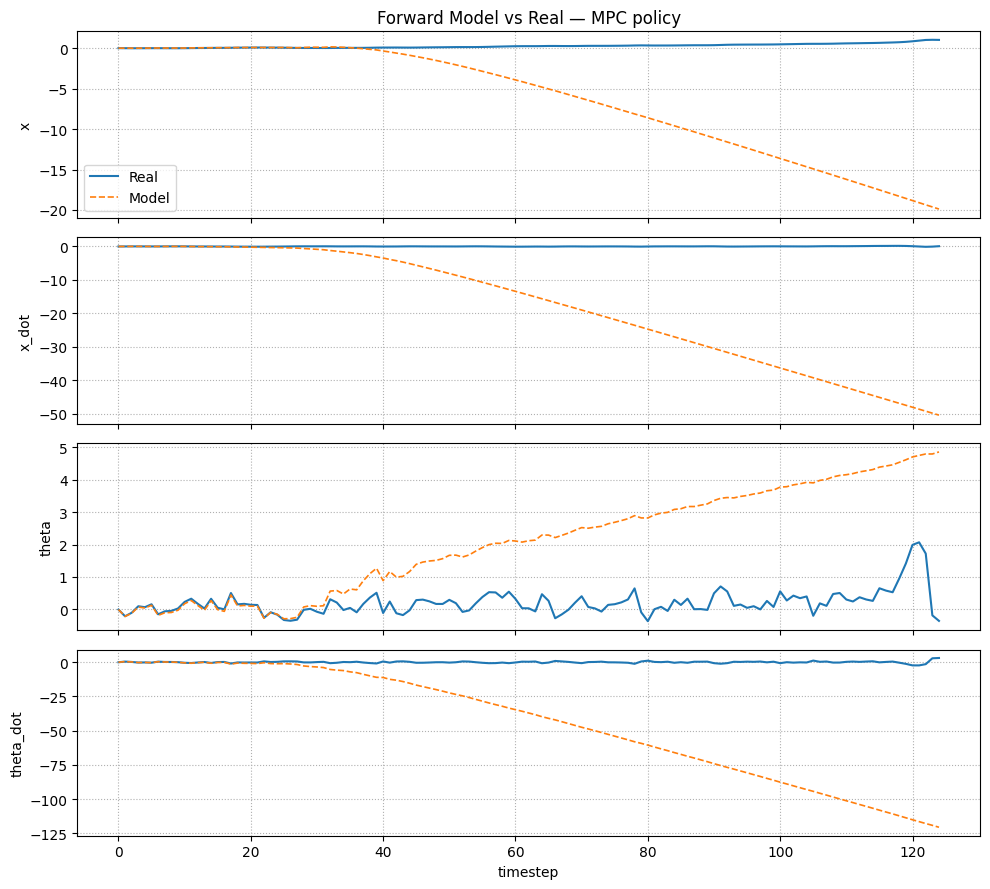

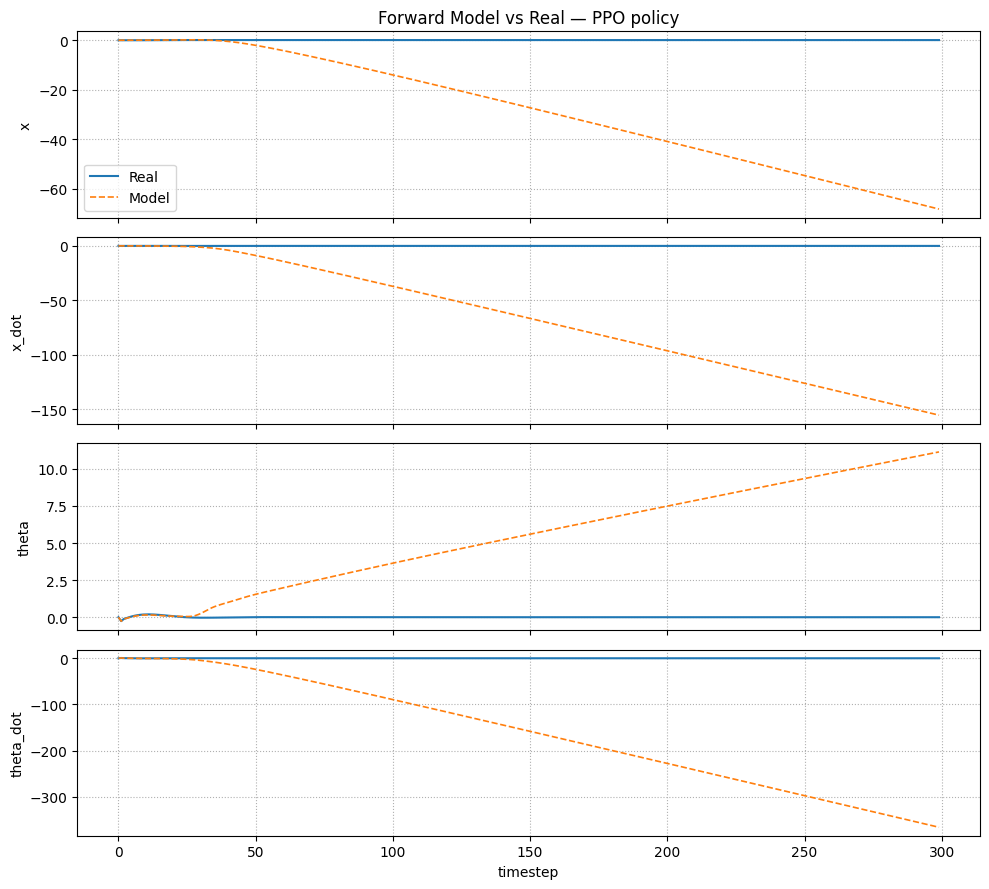

[Compare/Metrics] MPC: x_RMSE= 9.497604370117188 theta_RMSE= 2.365980386734009 seq_MSE_all= 1051.0968017578125
[Compare/Metrics] PPO: x_RMSE= 35.92683410644531 theta_RMSE= 6.431418418884277 seq_MSE_all= 11912.7822265625


In [15]:
def rollout_compare(model, env_id=ENV_ID, policy="MPC", horizon=300):
    env = gym.make(env_id)
    obs, _ = env.reset(seed=SEED+555)
    tmp = gym.make(env_id); low, high = float(tmp.action_space.low[0]), float(tmp.action_space.high[0]); tmp.close()

    if policy == "MPC":
        planner = RandomShootingMPC(model, low, high, horizon=20, n_samples=1024, device=device, sample_type="gaussian", gauss_std=1.0)
        def act_fn(s): return planner.act(s)
    else:
        def act_fn(s):
            a, _ = ppo_baseline.predict(s, deterministic=True)
            return a

    real=[]; acts=[]
    for t in range(horizon):
        a = act_fn(obs); acts.append(a.copy())
        nobs, r, done, trunc, _ = env.step(a)
        real.append(obs.copy()); obs=nobs
        if done or trunc: break
    env.close()
    real = np.array(real, dtype=np.float32); acts=np.array(acts, dtype=np.float32)

    s = torch.tensor(real[0], device=device).unsqueeze(0)
    preds=[real[0].copy()]
    with torch.no_grad():
        for t in range(1, len(real)):
            a_t = torch.tensor(acts[t-1], device=device).unsqueeze(0)
            s = model.step(s, a_t)
            preds.append(s.squeeze(0).cpu().numpy())
    preds = np.array(preds, dtype=np.float32)
    return real, preds

real_mpc, pred_mpc = rollout_compare(fm2, policy="MPC", horizon=300)
real_ppo, pred_ppo = rollout_compare(fm2, policy="PPO", horizon=300)

labels = ["x", "x_dot", "theta", "theta_dot"]

def plot_series(real, pred, title):
    T=min(len(real), len(pred))
    fig,axes=plt.subplots(4,1,figsize=(10,9),sharex=True)
    for i,ax in enumerate(axes):
        ax.plot(real[:T,i], label="Real", linewidth=1.5)
        ax.plot(pred[:T,i], label="Model", linewidth=1.2, linestyle="--")
        ax.set_ylabel(labels[i]); ax.grid(True, linestyle=":")
        if i==0: ax.set_title(title)
    axes[-1].set_xlabel("timestep"); axes[0].legend(); plt.tight_layout(); plt.show()

plot_series(real_mpc, pred_mpc, "Forward Model vs Real — MPC policy")
plot_series(real_ppo, pred_ppo, "Forward Model vs Real — PPO policy")

def rms(arr): return float(np.sqrt(np.mean(arr**2)))
def seq_mse(a,b): return float(np.mean((a-b)**2))

print("[Compare/Metrics] MPC:",
      "x_RMSE=", rms(pred_mpc[:,0]-real_mpc[:,0]),
      "theta_RMSE=", rms(pred_mpc[:,2]-real_mpc[:,2]),
      "seq_MSE_all=", seq_mse(pred_mpc, real_mpc))
print("[Compare/Metrics] PPO:",
      "x_RMSE=", rms(pred_ppo[:,0]-real_ppo[:,0]),
      "theta_RMSE=", rms(pred_ppo[:,2]-real_ppo[:,2]),
      "seq_MSE_all=", seq_mse(pred_ppo, real_ppo))

## 12) Return — MPC vs PPO (robust çizim)

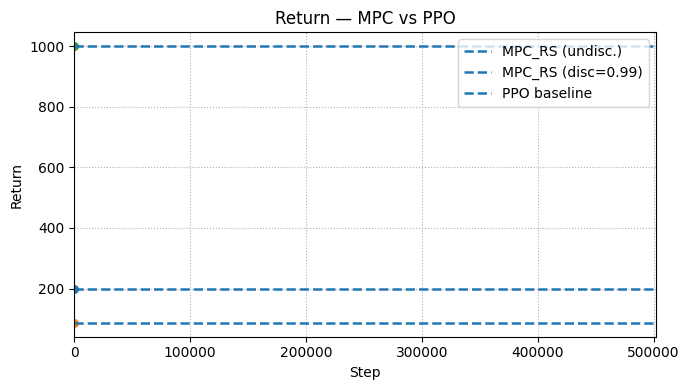

In [17]:
def tb_series(run_dir: str, tag: str):
    files=[]
    for root,_,fs in os.walk(run_dir):
        for f in fs:
            if f.startswith("events.out.tfevents"): files.append(os.path.join(root,f))
    if not files: return None
    dfs=[]
    for f in files:
        try:
            acc = ea.EventAccumulator(f, size_guidance={"scalars": 10**7}); acc.Reload()
            if tag in acc.Tags().get("scalars", []):
                s = acc.Scalars(tag)
                dfs.append(pd.DataFrame({"step":[i.step for i in s], "val":[i.value for i in s]}))
        except Exception as e:
            print("[WARN] TB okunamadı:", f, e)
    if not dfs: return None
    df = pd.concat(dfs).groupby("step", as_index=False)["val"].mean().sort_values("step")
    return df

def read_max_steps_from_csv(log_dir: str):
    csv_path = os.path.join(log_dir, "progress.csv")
    if not os.path.exists(csv_path): return None
    try:
        df = pd.read_csv(csv_path)
        for c in ["time/total_timesteps","timesteps","total_timesteps"]:
            if c in df.columns: return int(np.nanmax(df[c].values))
    except: pass
    return None

def plot_series_or_horizontal(log_dir: str, label: str, fallback_value=None, x_max=None, tag="eval/return_mean"):
    df = tb_series(log_dir, tag)
    if df is not None and len(df) >= 2:
        plt.plot(df["step"], df["val"], label=label, linewidth=1.8); return int(df["step"].max())
    val=None
    if df is not None and len(df)==1: val=float(df["val"].iloc[0])
    elif fallback_value is not None: val=float(fallback_value)
    if val is not None:
        if x_max is None or x_max<=0: x_max=1
        plt.hlines(val, xmin=0, xmax=x_max, linestyles="--", linewidth=1.8, label=label)
        plt.scatter([0],[val], s=30); return x_max
    return None

xmax_ppocsv = read_max_steps_from_csv(BASE_LOG)
plt.figure(figsize=(7,4))
x1 = plot_series_or_horizontal(MPC_LOG,  "MPC_RS (undisc.)", fallback_value=globals().get("mpc_mean", None), x_max=xmax_ppocsv, tag="eval/return_mean")
x2 = plot_series_or_horizontal(MPC_LOG,  "MPC_RS (disc=0.99)", fallback_value=globals().get("mpc_disc_mean", None), x_max=xmax_ppocsv, tag="eval/return_mean_discounted")
x3 = plot_series_or_horizontal(BASE_LOG, "PPO baseline",      fallback_value=globals().get("mean_r", None), x_max=xmax_ppocsv, tag="eval/return_mean")
xmax = max([v for v in [x1,x2,x3,xmax_ppocsv] if v is not None] or [1])
plt.xlim(0, xmax); plt.title("Return — MPC vs PPO"); plt.xlabel("Step"); plt.ylabel("Return")
plt.grid(True, linestyle=":", linewidth=0.8); plt.legend(); plt.tight_layout(); plt.show()

## 13) Pygame Render — MPC & PPO

In [ ]:
# %pip install pygame  # gerekirse
import numpy as np, pygame
def _make_rgb_env(env_id=ENV_ID, seed=SEED):
    env = gym.make(env_id, render_mode="rgb_array"); obs, info = env.reset(seed=seed); return env, obs
def _pygame_init(width, height, title="RL Demo"):
    pygame.init(); surf = pygame.display.set_mode((width, height)); pygame.display.set_caption(title); clock = pygame.time.Clock(); return surf, clock
def _pygame_frame(surf, frame):
    frame = np.ascontiguousarray(frame); h,w = frame.shape[:2]
    pg_surface = pygame.image.frombuffer(frame.tobytes(), (w,h), "RGB"); surf.blit(pg_surface,(0,0)); pygame.display.flip()
def _handle_events():
    for event in pygame.event.get():
        if event.type == pygame.QUIT: return True
        if event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE: return True
    return False
def render_demo(policy="MPC", episodes=2, max_steps=500, fps=30, gaussian_std=1.0):
    assert policy in ["MPC","PPO"]
    env, obs = _make_rgb_env(); first = env.render(); H,W = first.shape[0], first.shape[1]
    surf, clock = _pygame_init(W, H, title=f"{policy} Demo — {ENV_ID}")
    tmp = gym.make(ENV_ID); low, high = float(tmp.action_space.low[0]), float(tmp.action_space.high[0]); tmp.close()
    if policy == "MPC":
        demo_planner = RandomShootingMPC(fm2, low, high, horizon=25, n_samples=1024, device=device, sample_type="gaussian", gauss_std=gaussian_std)
        def act_fn(s): return demo_planner.act(s)
    else:
        def act_fn(s):
            a, _ = ppo_baseline.predict(s, deterministic=True); return a
    try:
        for ep in range(episodes):
            obs, info = env.reset(seed=SEED+100+ep); ret=0.0
            for t in range(max_steps):
                if _handle_events(): print("[INFO] Demo kapandı."); return
                a = act_fn(obs); obs, r, done, trunc, _ = env.step(a); ret += r
                frame = env.render(); _pygame_frame(surf, frame); clock.tick(fps)
                if done or trunc: break
            print(f"[{policy} DEMO] Ep {ep+1}/{episodes} return={ret:.1f}")
    finally:
        pygame.quit(); env.close()

# Örnek:
#render_demo(policy="MPC", episodes=2, max_steps=400, fps=30, gaussian_std=1.0)
render_demo(policy="PPO", episodes=2, max_steps=400, fps=30)

[PPO DEMO] Ep 1/2 return=400.0
[PPO DEMO] Ep 2/2 return=400.0
[PPO DEMO] Ep 2/2 return=400.0


: 

## 14) Meta

In [14]:
meta = {
    "phase": PHASE, "notebook": NOTEBOOK, "step": STEP, "env": ENV_ID, "seed": SEED,
    "root_dir": boot.root_dir, "run_id": boot.run_id,
    "fm_log": FM_LOG, "mpc_log": MPC_LOG, "base_log": BASE_LOG, "data_log": DATA_LOG,
    "ckpt_fm": CKPT_FM_DIR, "ckpt_mpc": CKPT_MPC_DIR, "ckpt_base": CKPT_BASE_DIR
}
with open(os.path.join(boot.root_dir, "meta.json"), "w") as f: json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))

{
  "phase": "Phase 1",
  "notebook": "21_forward_model_inverted_pendulum",
  "step": "ForwardModel+RS-MPC+NoisyPPO",
  "env": "InvertedPendulum-v4",
  "seed": 42,
  "root_dir": "runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6",
  "run_id": "20251009-130558-a36ed6",
  "fm_log": "runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6/ForwardModel_InvertedPendulum_v4",
  "mpc_log": "runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6/MPC_RS_InvertedPendulum_v4",
  "base_log": "runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6/Baseline_PPO_InvertedPendulum_v4",
  "data_log": "runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6/DataGen_InvertedPendulum_v4",
  "ckpt_fm": "runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6/checkpoints/ForwardModel_InvertedPendulum_v4",
  "ckpt_mpc": "runs/Phase 1/21_forward_model_inverted_pendulum/20251009-130558-a36ed6/checkpoints/MPC_RS_Inv